# Student Pass Predictor
#### For this ML project we will use the CRISP-DM methodology:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

### 1. Business Understanding
A school wants to develop a student pass predictor to estimate if a student will pass or not.
The school have the following data for each student:
- Hours of study per week
- Attendance percentage

The variable we want to predict is **Result**, this variable can store two possible values:
- Pass
- Fail

### 2. Data Understanding

In [1]:
data = {
    "study_hours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 8,
        9, 9, 10, 10, 4,
        6, 7, 3, 8, 5,
        9, 2, 10, 6, 4
    ],

    "attendance": [
        50, 55, 70, 60, 80,
        65, 85, 60, 75, 70,
        90, 65, 85, 70, 95,
        80, 90, 85, 95, 75,
        78, 88, 58, 92, 68,
        82, 62, 98, 72, 66
    ],

    "result": [
        "Fail", "Fail", "Fail", "Fail", "Fail",
        "Fail", "Fail", "Fail", "Pass", "Pass",
        "Pass", "Fail", "Pass", "Pass", "Pass",
        "Pass", "Pass", "Pass", "Pass", "Fail",
        "Pass", "Pass", "Fail", "Pass", "Fail",
        "Pass", "Fail", "Pass", "Pass", "Fail"
    ]
}

In [2]:
import pandas as pd

students_df = pd.DataFrame(data)

students_df

,study_hours,attendance,result
0,1,50,Fail
1,2,55,Fail
2,2,70,Fail
3,3,60,Fail
4,3,80,Fail
5,4,65,Fail
6,4,85,Fail
7,5,60,Fail
8,5,75,Pass
9,6,70,Pass


#### EDA (Exploratory Data Analysis)

In [3]:
students_df.head()

,study_hours,attendance,result
0,1,50,Fail
1,2,55,Fail
2,2,70,Fail
3,3,60,Fail
4,3,80,Fail


In [4]:
students_df.tail()

,study_hours,attendance,result
25,9,82,Pass
26,2,62,Fail
27,10,98,Pass
28,6,72,Pass
29,4,66,Fail


In [5]:
students_df.shape

(30, 3)

In [6]:
students_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   study_hours  30 non-null     int64
 1   attendance   30 non-null     int64
 2   result       30 non-null     str  
dtypes: int64(2), str(1)
memory usage: 852.0 bytes


In [7]:
students_df.describe()

,study_hours,attendance
count,30.000000,30.000000
mean,5.766667,75.466667
std,2.674056,13.111546
min,1.000000,50.000000
25%,4.000000,65.250000
50%,6.000000,75.000000
75%,8.000000,85.000000
max,10.000000,98.000000


In [8]:
# Missing values
students_df.isnull().sum()

study_hours    0
attendance     0
result         0
dtype: int64

In [9]:
# Duplicated Values
students_df.duplicated().sum()

np.int64(0)

In [10]:
# Frequency of study_hours column
students_df["study_hours"].value_counts()

study_hours
4     4
6     4
2     3
3     3
5     3
7     3
8     3
9     3
10    3
1     1
Name: count, dtype: int64

In [11]:
# Frequency of attendance column
students_df["attendance"].value_counts()

attendance
70    3
85    3
60    2
80    2
65    2
75    2
90    2
95    2
50    1
55    1
78    1
88    1
58    1
92    1
68    1
82    1
62    1
98    1
72    1
66    1
Name: count, dtype: int64

In [12]:
# Frequency of result column
students_df["result"].value_counts()

result
Pass    16
Fail    14
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of study hours')

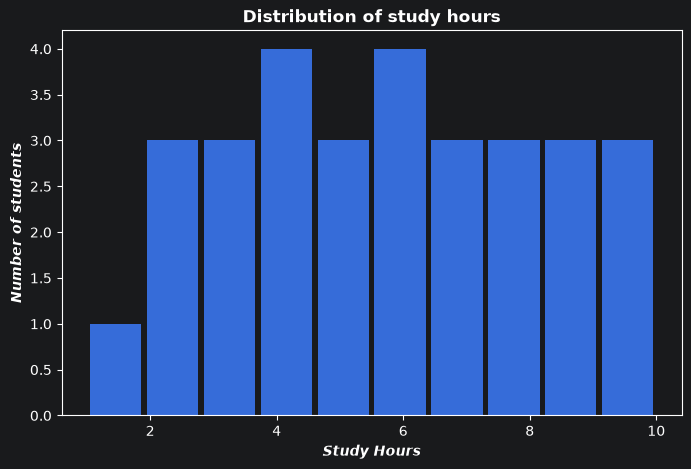

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))

plt.hist(students_df["study_hours"], bins = 10, rwidth = 0.9)

plt.xlabel("Study Hours", fontstyle = "italic", weight = "bold")
plt.ylabel("Number of students", fontstyle = "italic", weight = "bold")
plt.title("Distribution of study hours", weight = "bold")

Text(0.5, 1.0, 'Distribution of Attendance')

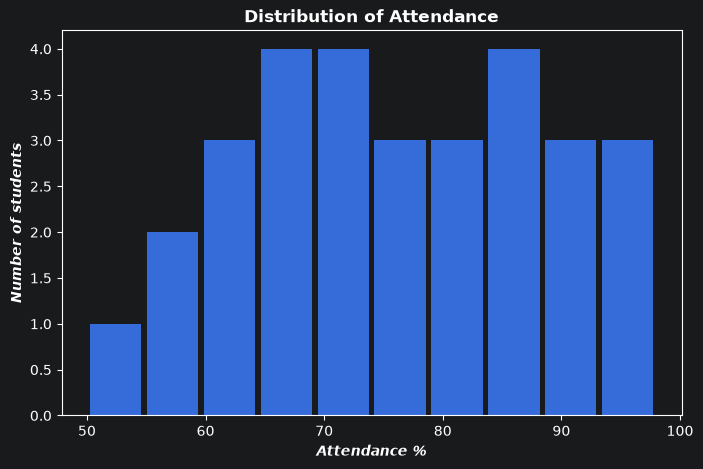

In [14]:
plt.figure(figsize = (8, 5))

plt.hist(students_df["attendance"], bins = 10, rwidth = 0.9)

plt.xlabel("Attendance %", fontstyle = "italic", weight = "bold")
plt.ylabel("Number of students", fontstyle = "italic", weight = "bold")
plt.title("Distribution of Attendance", weight = "bold")

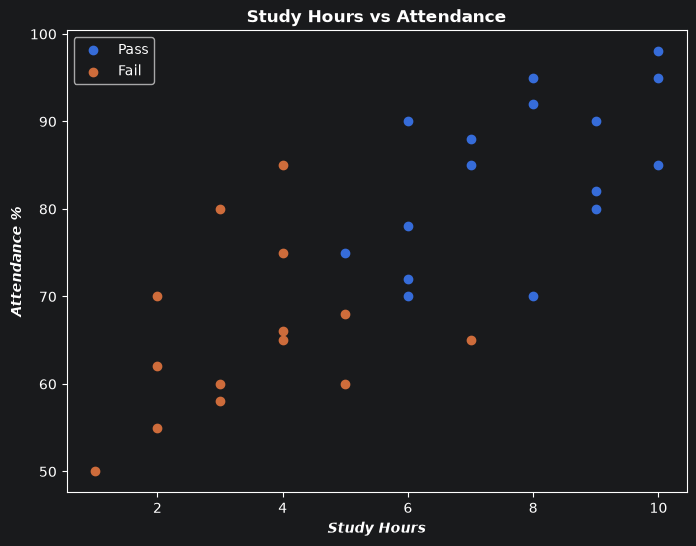

In [15]:
plt.figure(figsize = (8, 6))

for i in ["Pass", "Fail"]:
    group = students_df[students_df["result"] == i]

    plt.scatter(
        group["study_hours"],
        group["attendance"],
        label = i
    )

plt.xlabel("Study Hours", weight = "bold", fontstyle = "italic")
plt.ylabel("Attendance %", weight = "bold", fontstyle = "italic")
plt.title("Study Hours vs Attendance", weight = "bold")
plt.legend()

In [16]:
# Average study hours and attendance

students_df.groupby("result")[["study_hours", "attendance"]].mean()

,study_hours,attendance
result,,
Fail,3.50,65.642857
Pass,7.75,84.062500


In [17]:
# Correlation

status = {"Pass": 1, "Fail": 0}

students_df["result"] = students_df['result'].map(status)
students_df.corr()

,study_hours,attendance,result
study_hours,1.000000,0.758546,0.806460
attendance,0.758546,1.000000,0.712839
result,0.806460,0.712839,1.000000


### 3. Data Preparation

Input variables:
- study_hours
- attendance

In [18]:
X = students_df[["study_hours", "attendance"]]

Y = students_df["result"]

In [19]:
X.head()

,study_hours,attendance
0,1,50
1,2,55
2,2,70
3,3,60
4,3,80


In [20]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: result, dtype: int64

#### Training Data and Testing Data
- 70% for training
- 30% for testing

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.30,
    random_state = 42,
    stratify = Y
)

In [25]:
print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}"

Training Data: (21, 2)
Testing Data: (9, 2)


### 4. Modeling
We will build a **decision tree** to our model, the model will obtain rules to predict if a student pass or fail:


In [27]:
# Creating the ML model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth = 3, random_state = 42)

# Training
model.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

#### Tree Diagram

[Text(0.4, 0.8333333333333334, 'Study Hours <= 4.5\ngini = 0.499\nsamples = 21\nvalue = [10, 11]\nclass = Pass'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]\nclass = Fail'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'Attendance <= 69.0\ngini = 0.26\nsamples = 13\nvalue = [2, 11]\nclass = Pass'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = Fail'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]\nclass = Pass')]

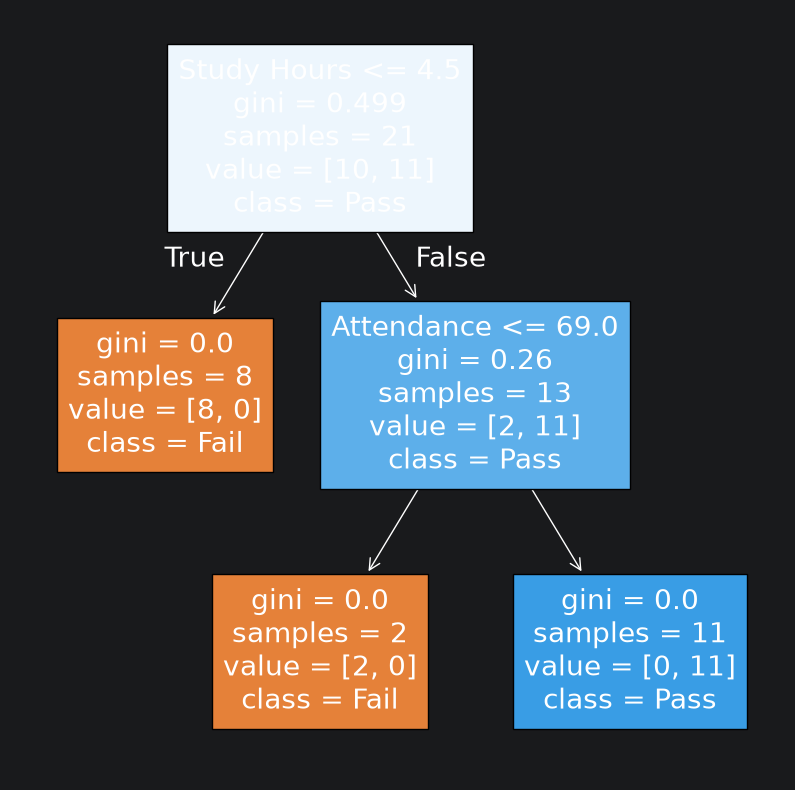

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize = (10, 10))

plot_tree(
    model,
    feature_names = ["Study Hours", "Attendance"],
    class_names = ["Fail", "Pass"],
    filled = True
)

#### Rules of our decision tree:

In [36]:
from sklearn.tree import export_text

rules = export_text(
    model,
    feature_names = [
        "study_hours",
        "attendance"
    ]
)

print(rules)

|--- study_hours <= 4.50
|   |--- class: 0
|--- study_hours >  4.50
|   |--- attendance <= 69.00
|   |   |--- class: 0
|   |--- attendance >  69.00
|   |   |--- class: 1



### 5. Evaluation
We will use the testing data:

In [37]:
predictions = model.predict(X_test)

In [38]:
result = X_test.copy()

result["real"] = Y_test
result["prediction"] = predictions

print(result)

    study_hours  attendance  real  prediction
3             3          60     0           0
10            6          90     1           1
28            6          72     1           1
13            8          70     1           1
22            3          58     0           0
14            8          95     1           1
16            9          90     1           1
7             5          60     0           0
6             4          85     0           0


#### Accuracy of our model:

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, predictions)

print(f"Accuracy: {round(accuracy * 100, 2)}%") # If we decrease the max_depth of our model the accuracy will be worse

Accuracy: 100.0%


#### Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_test, predictions))

[[4 0]
 [0 5]]


#### Clasification Report

In [48]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



### 6. Deployment

In [49]:
def studentPassPredictor(study_hours, attendance_percentage):
    new = pd.DataFrame({
        "study_hours": [study_hours],
        "attendance": [attendance_percentage]
    })

    prediction = model.predict(new)[0]

    if prediction == 1:
        return "Pass"
    else:
        return "Fail"

#### Testing our model:

In [50]:
print(studentPassPredictor(8, 90))

Pass


In [52]:
print(studentPassPredictor(15, 40))

Fail


In [53]:
print(studentPassPredictor(12, 70))

Pass
